# visual evaluation:

the original MRI `AORTA_274_0000.nii.gz`

the manual mask `sample_data\ao_segs\AORTA_274.nii.gz`

the inferenced mask `nnUNet_raw\Dataset201_AORTA_MRI\labelsTs\AORTA_274.nii.gz` 

In [4]:
import os
import random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path


In [9]:
BASE_DIR = os.path.dirname(os.path.abspath(os.getcwd()))
# print(BASE_DIR)
RAW_DATA_DIR = os.path.join(BASE_DIR, '/workspace/sample_data')


DATA_DIR = Path(RAW_DATA_DIR)
AO_IMGS_DIR = DATA_DIR / "ao_imgs"
AO_SEGS_DIR = DATA_DIR / "ao_segs"
INFRENCED_DATA_DIR = Path(os.path.join(BASE_DIR, '/workspace/nnUNet_raw/Dataset201_AORTA_MRI')) / "labelsTs"
img_files = sorted(AO_IMGS_DIR.glob("*.nii.gz"))
seg_files = sorted(AO_SEGS_DIR.glob("*.nii.gz"))
infrenced_seg_files = sorted(INFRENCED_DATA_DIR.glob("*.nii.gz"))

print(f"Found {len(img_files)} images and {len(seg_files)} segmentations and infrenced segmentations {len(infrenced_seg_files)}")

Found 359 images and 359 segmentations and infrenced segmentations 359


In [16]:
NUM_SAMPLES = 4
random.seed(42)
sample_indices = random.sample(range(len(img_files)), NUM_SAMPLES)

sample_imgs = [img_files[i] for i in sample_indices]
sample_segs = [seg_files[i] for i in sample_indices]
sample_infrenced_segs = [infrenced_seg_files[i] for i in sample_indices]

print("Selected sample indices:", sample_indices)

Selected sample indices: [327, 57, 12, 140]


In [ ]:
def load_nifti(filepath):
    img = nib.load(str(filepath))
    return img.get_fdata(), img.affine, img.header
    
def visualize_mip(img_data, seg_data):
    mip_img = np.max(img_data, axis=2)
    mip_seg = np.max(seg_data, axis=2)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(mip_img.T, cmap="gray", origin="lower")
    plt.title("MIP - MRI Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mip_seg.T, cmap="jet", origin="lower")
    plt.title("MIP - Segmentation")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(mip_img.T, cmap="gray", origin="lower")
    plt.imshow(mip_seg.T, cmap="jet", alpha=0.5, origin="lower")
    plt.title("MIP - Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


print("MANUAL SEGMENTATION")
for img_path, seg_path in zip(sample_imgs, sample_segs):
    img_data, _, _ = load_nifti(img_path)
    seg_data, _, _ = load_nifti(seg_path)
    print(f"Image: {img_path.name}")
    visualize_mip(img_data, seg_data)
    print("-" * 80)

print("INFRENCED SEGMENTATION")

for img_path, seg_path in zip(sample_imgs, sample_infrenced_segs):
    img_data, _, _ = load_nifti(img_path)
    seg_data, _, _ = load_nifti(seg_path)
    print(f"Image: {img_path.name}")
    visualize_mip(img_data, seg_data)
    print("-" * 80)


COMPARISON: MANUAL vs INFERRED
Image: AORTA_70752_0000.nii.gz


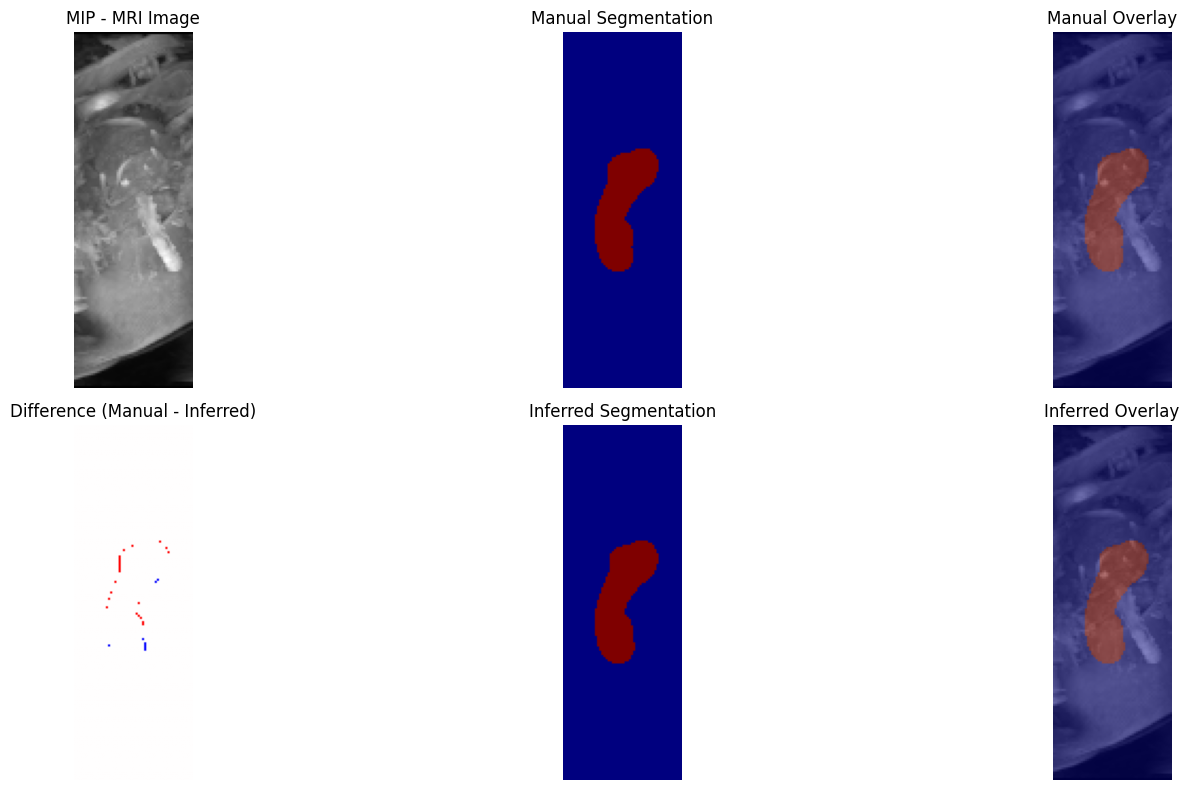

--------------------------------------------------------------------------------
Image: AORTA_29278_0000.nii.gz


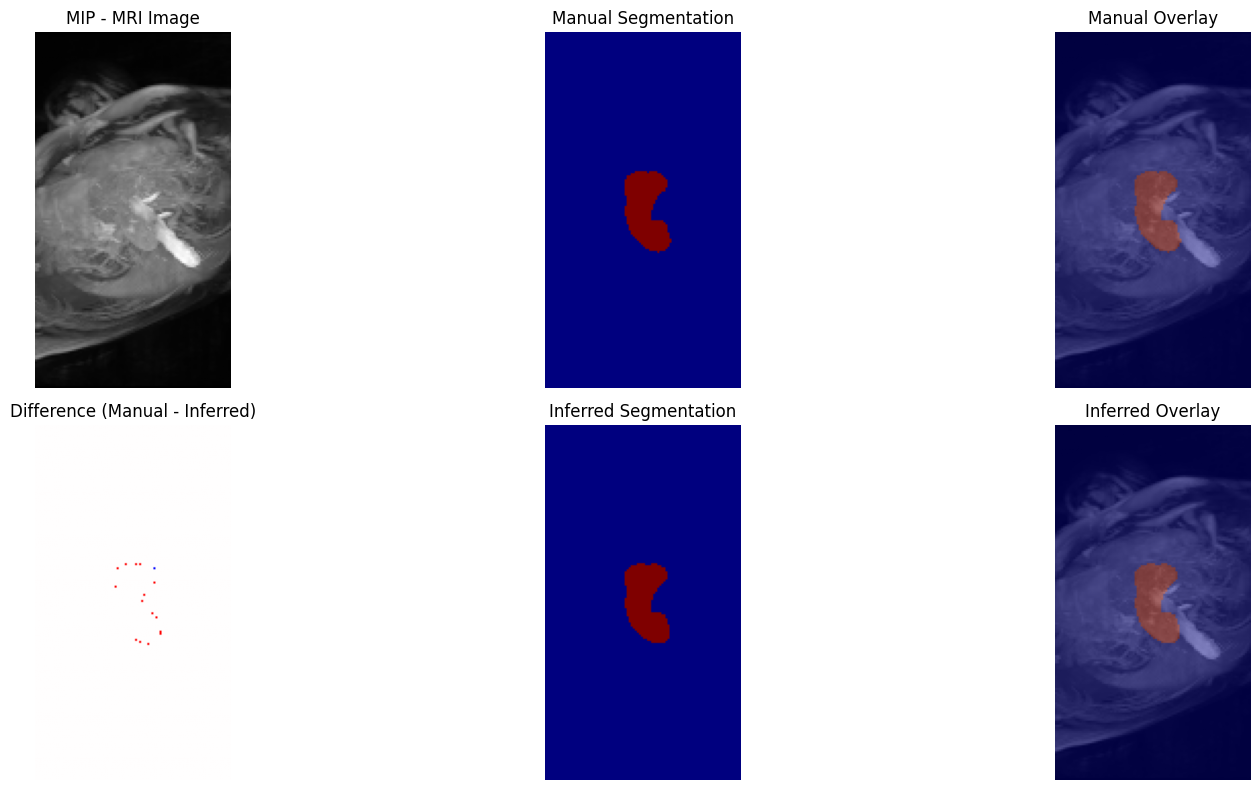

--------------------------------------------------------------------------------
Image: AORTA_27624_0000.nii.gz


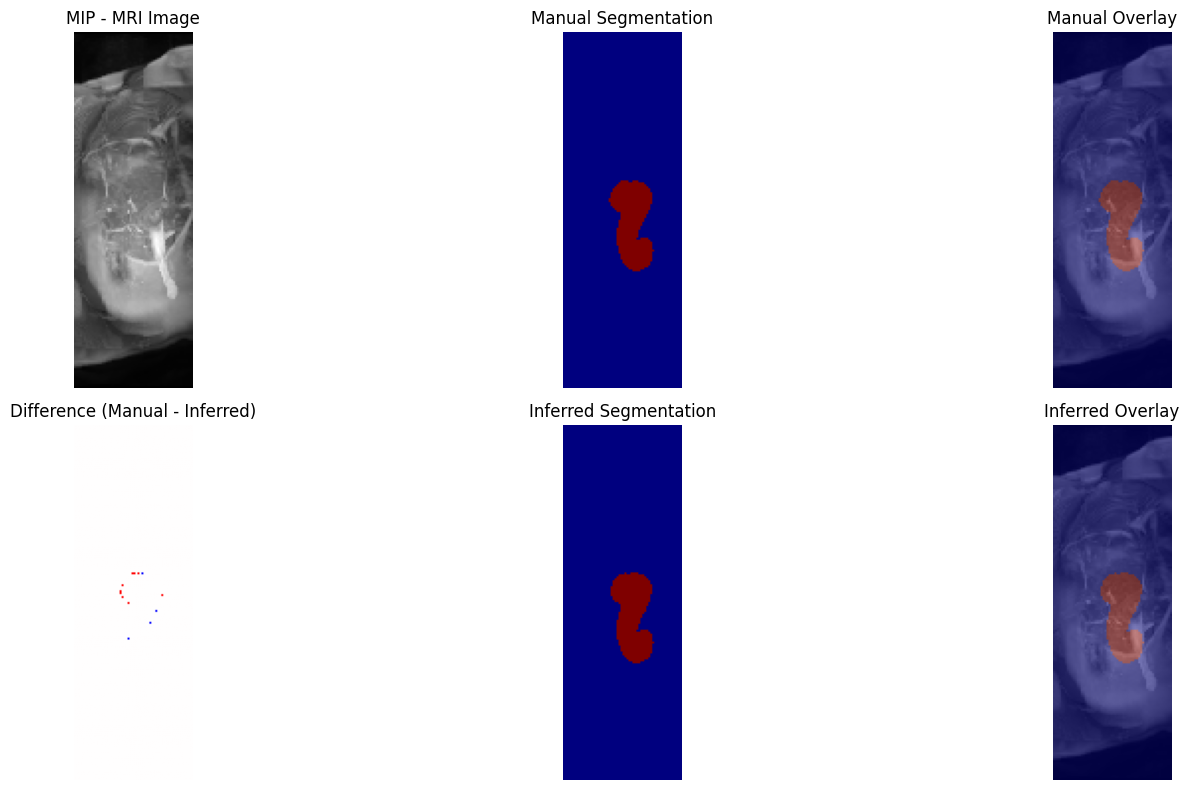

--------------------------------------------------------------------------------
Image: AORTA_31311_0000.nii.gz


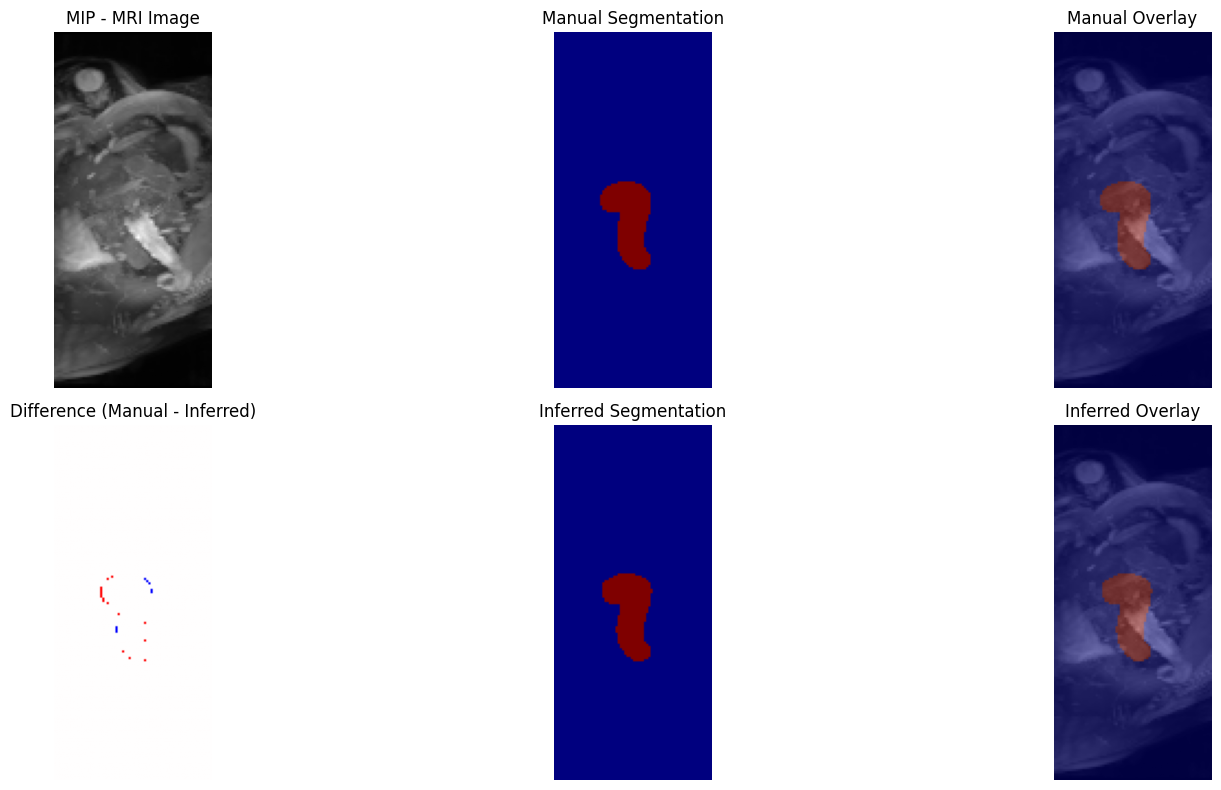

--------------------------------------------------------------------------------


In [18]:
def visualize_comparison(img_data, manual_seg, inferred_seg):
    mip_img = np.max(img_data, axis=2)
    mip_manual = np.max(manual_seg, axis=2)
    mip_inferred = np.max(inferred_seg, axis=2)

    plt.figure(figsize=(18, 8))

    # Original
    plt.subplot(2, 3, 1)
    plt.imshow(mip_img.T, cmap="gray", origin="lower")
    plt.title("MIP - MRI Image")
    plt.axis("off")

    # Manual mask
    plt.subplot(2, 3, 2)
    plt.imshow(mip_manual.T, cmap="jet", origin="lower")
    plt.title("Manual Segmentation")
    plt.axis("off")

    # Manual overlay
    plt.subplot(2, 3, 3)
    plt.imshow(mip_img.T, cmap="gray", origin="lower")
    plt.imshow(mip_manual.T, cmap="jet", alpha=0.5, origin="lower")
    plt.title("Manual Overlay")
    plt.axis("off")

    # Inferred mask
    plt.subplot(2, 3, 5)
    plt.imshow(mip_inferred.T, cmap="jet", origin="lower")
    plt.title("Inferred Segmentation")
    plt.axis("off")

    # Inferred overlay
    plt.subplot(2, 3, 6)
    plt.imshow(mip_img.T, cmap="gray", origin="lower")
    plt.imshow(mip_inferred.T, cmap="jet", alpha=0.5, origin="lower")
    plt.title("Inferred Overlay")
    plt.axis("off")

    # Difference (optional but useful!)
    diff = mip_manual - mip_inferred
    plt.subplot(2, 3, 4)
    plt.imshow(diff.T, cmap="bwr", origin="lower")
    plt.title("Difference (Manual - Inferred)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


print("COMPARISON: MANUAL vs INFERRED")

for img_path, manual_path, inferred_path in zip(sample_imgs, sample_segs, sample_infrenced_segs):
    img_data, _, _ = load_nifti(img_path)
    manual_seg, _, _ = load_nifti(manual_path)
    inferred_seg, _, _ = load_nifti(inferred_path)

    print(f"Image: {img_path.name}")
    visualize_comparison(img_data, manual_seg, inferred_seg)
    print("-" * 80)


In [19]:
import numpy as np
from scipy.spatial.distance import cdist

# ---------- Metrics ---------- #

def dice_score(gt, pred):
    gt = gt > 0
    pred = pred > 0
    intersection = np.sum(gt * pred)
    return (2. * intersection) / (np.sum(gt) + np.sum(pred) + 1e-8)


def iou_score(gt, pred):
    gt = gt > 0
    pred = pred > 0
    intersection = np.sum(gt & pred)
    union = np.sum(gt | pred)
    return intersection / (union + 1e-8)


def precision(gt, pred):
    gt = gt > 0
    pred = pred > 0
    tp = np.sum(gt & pred)
    fp = np.sum(~gt & pred)
    return tp / (tp + fp + 1e-8)


def recall(gt, pred):
    gt = gt > 0
    pred = pred > 0
    tp = np.sum(gt & pred)
    fn = np.sum(gt & ~pred)
    return tp / (tp + fn + 1e-8)


# ---------- Hausdorff Distance (HD95) ---------- #
def hausdorff_95(gt, pred):
    gt_points = np.argwhere(gt > 0)
    pred_points = np.argwhere(pred > 0)

    if len(gt_points) == 0 or len(pred_points) == 0:
        return np.nan

    distances = cdist(gt_points, pred_points)
    
    hd1 = np.percentile(np.min(distances, axis=1), 95)
    hd2 = np.percentile(np.min(distances, axis=0), 95)

    return max(hd1, hd2)


# ---------- Evaluation Loop ---------- #

results = []

for img_path, gt_path, pred_path in zip(sample_imgs, sample_segs, sample_infrenced_segs):

    img_data, _, _ = load_nifti(img_path)
    gt, _, _ = load_nifti(gt_path)
    pred, _, _ = load_nifti(pred_path)

    d = dice_score(gt, pred)
    iou = iou_score(gt, pred)
    p = precision(gt, pred)
    r = recall(gt, pred)
    hd = hausdorff_95(gt, pred)

    print(f"Image: {img_path.name}")
    print(f"Dice: {d:.4f}")
    print(f"IoU: {iou:.4f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall: {r:.4f}")
    print(f"HD95: {hd:.2f}")
    print("-" * 50)

    results.append([d, iou, p, r, hd])

# ---------- Summary ---------- #

results = np.array(results)

print("\n===== DATASET SUMMARY =====")
print(f"Mean Dice: {np.nanmean(results[:,0]):.4f} ± {np.nanstd(results[:,0]):.4f}")
print(f"Mean IoU: {np.nanmean(results[:,1]):.4f}")
print(f"Mean Precision: {np.nanmean(results[:,2]):.4f}")
print(f"Mean Recall: {np.nanmean(results[:,3]):.4f}")
print(f"Mean HD95: {np.nanmean(results[:,4]):.2f}")

Image: AORTA_70752_0000.nii.gz
Dice: 0.9748
IoU: 0.9509
Precision: 0.9753
Recall: 0.9743
HD95: 0.00
--------------------------------------------------
Image: AORTA_29278_0000.nii.gz
Dice: 0.9805
IoU: 0.9617
Precision: 0.9910
Recall: 0.9702
HD95: 0.00
--------------------------------------------------
Image: AORTA_27624_0000.nii.gz
Dice: 0.9739
IoU: 0.9491
Precision: 0.9815
Recall: 0.9663
HD95: 0.00
--------------------------------------------------
Image: AORTA_31311_0000.nii.gz
Dice: 0.9637
IoU: 0.9299
Precision: 0.9891
Recall: 0.9396
HD95: 1.00
--------------------------------------------------

===== DATASET SUMMARY =====
Mean Dice: 0.9732 ± 0.0060
Mean IoU: 0.9479
Mean Precision: 0.9842
Mean Recall: 0.9626
Mean HD95: 0.25


# ✅ nnU-Net Segmentation Evaluation Interpretation

## 📊 Overall Performance Summary

The model demonstrates **excellent segmentation performance** on the aorta MRI dataset:

- **Mean Dice Score:** 0.9732 ± 0.0060  
- **Mean IoU:** 0.9479  
- **Mean Precision:** 0.9842  
- **Mean Recall:** 0.9626  
- **Mean HD95:** 0.25  

👉 These values indicate **very high agreement** between predicted and manual segmentations, both in terms of overlap and boundary accuracy.

---

## 🔥 Dice Score (Primary Metric)

- The Dice score is **consistently above 0.96** for all cases.
- Low standard deviation (±0.006) shows **stable performance across samples**.

✅ **Interpretation:**  
The model produces segmentations that almost perfectly match the ground truth, with very strong consistency.

---

## 🔷 Intersection over Union (IoU)

- IoU values are close to **0.95**, which is considered very high.

✅ **Interpretation:**  
This confirms that the overlap between predicted and ground truth masks is strong, even under stricter evaluation than Dice.

---

## 🎯 Precision vs Recall

- **Precision (0.9842)** is slightly higher than **Recall (0.9626)**

### ✅ What this means:

- The model produces **very clean segmentations** (few false positives)
- It occasionally **misses small regions of the aorta** (slight under-segmentation)

### 🔍 Insight:
This behavior indicates a **conservative model**, which is often desirable in medical imaging because:
- It avoids over-segmentation into surrounding tissues
- Errors are mostly small omissions rather than false additions

---

## 📐 Hausdorff Distance (HD95)

- Mean HD95 is **0.25**
- Most cases have **HD95 = 0.00**, with one case at **1.00**

✅ **Interpretation:**  
The predicted boundaries are **extremely close to the ground truth**, often nearly identical.

- Very low HD95 indicates excellent **boundary localization**
- The single higher value suggests **minor edge differences**

---

## 🧠 Model Behavior Summary

Your nnU-Net model is:

✅ Highly accurate  
✅ Very consistent across cases  
✅ Producing clean (low-noise) segmentations  
✅ Precisely capturing anatomical boundaries  

⚠️ Minor limitation:
- Slight tendency toward **under-segmentation** (missing small regions)



## ⚠️ Important Consideration

- The evaluation was performed on a **small sample (4 cases)**

👉 This means:
- Results are **very promising**
- But should be validated on a **larger and more diverse dataset** to confirm generalization

---

## ✅ Final Conclusion

> The model achieves **near state-of-the-art performance**, with highly accurate overlap, excellent boundary precision, and consistent predictions across cases. Minor under-segmentation is the only noticeable limitation.

---